In [1]:
PAC5_files = {
    "contact_1": "../../PAC5_100_1/10_contact/con_results.pkl",
    "contact_2": "../../PAC5_100_2/10_contact/con_results.pkl",
    "contact_3": "../../PAC5_500_3/10_contact/con_results.pkl",
    "MMPBSA__1": "../../PAC5_100_1/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat",
    "MMPBSA__2": "../../PAC5_100_2/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat",
    "MMPBSA__3": "../../PAC5_500_3/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat"
}

RNA_files = {
    "contact_1": "../../RNA_100_1/10_contact/con_results.pkl",
    "contact_2": "../../RNA_100_2/10_contact/con_results.pkl",
    "contact_3": "../../RNA_500_3/10_contact/con_results.pkl",
    "MMPBSA__1": "../../RNA_100_1/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat",
    "MMPBSA__2": "../../RNA_100_2/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat",
    "MMPBSA__3": "../../RNA_500_3/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat"
}

ssDNA_files = {
    "contact_1": "../../ssDNA_100_1/10_contact/con_results.pkl",
    "contact_2": "../../ssDNA_100_2/10_contact/con_results.pkl",
    "contact_3": "../../ssDNA_500_3/10_contact/con_results.pkl",
    "MMPBSA__1": "../../ssDNA_100_1/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat",
    "MMPBSA__2": "../../ssDNA_100_2/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat",
    "MMPBSA__3": "../../ssDNA_500_3/9_MMPBSA/FINAL_DECOMP_MMPBSA.dat"
}

In [2]:
import pickle
import pandas as pd
def get_ave_dist(fileDic, sysName):
    path_list = [(fileDic["contact_1"], 1), (fileDic["contact_2"], 2), (fileDic["contact_3"], 3)]
    def getPklDf(info):
        with open(info[0], "rb") as distFile:
            dist_df = pickle.load(distFile)
        dist_df = dist_df.iloc[:, :-1]
        dist_df = dist_df.T
        dist_df["Mean"] = dist_df.mean(axis=1)
        dist_df = dist_df.reset_index()[["index", "Mean"]]
        dist_df.columns = ["ResID", f"meanDistence_{info[1]}"]
        return dist_df

    dist_df = getPklDf(path_list[0])
    for info in path_list[1:]:
        dist_df_tmp = getPklDf(info)
        dist_df = pd.merge(dist_df, dist_df_tmp, on="ResID", how='inner')

    dist_df[f"avg_Dist_{sysName}"] = dist_df[
        ['meanDistence_1', 'meanDistence_2', 'meanDistence_3']
        ].mean(axis=1)
    
    dist_df = dist_df[["ResID", f"avg_Dist_{sysName}"]]

    return dist_df

PAC5_dist_df  = get_ave_dist(PAC5_files , "PAC5")
RNA_dist_df   = get_ave_dist(RNA_files  , "RNA")
ssDNA_dist_df = get_ave_dist(ssDNA_files, "ssDNA")

In [3]:
import pandas as pd
import io
def read_deBFE(info):
    # 1. 把整段结果保存成字符串
    with open(info[0], 'r') as f:
        raw = f.read()
    # 2. 定位到“DELTAS: Total Energy Decomposition”这一段
    start = raw.find("DELTAS:\nTotal Energy Decomposition:")
    stop  = raw.find("Sidechain Energy Decomposition:", start)   # 下一段之前结束
    block = raw[start:stop]
    # 3. 用 pandas 读表格
    df = pd.read_csv(
            io.StringIO(block),
            sep=',',     # 逗号或≥2个空格都当分隔符
            engine='python',
            skiprows=4,               # 跳过标题行
            header=None
    )
    # 4. 手工给列命名
    df.columns = ['Residue','Int_Avg','Int_Std','Int_StdErr',
                  'VDW_Avg','VDW_Std','VDW_StdErr',
                  'ELE_Avg','ELE_Std','ELE_StdErr',
                  'POL_Avg','POL_Std','POL_StdErr',
                  'NPOL_Avg','NPOL_Std','NPOL_StdErr',
                  f'TOT_Avg_{info[1]}','TOT_Std','TOT_StdErr']
    df = df.dropna(subset=['Residue'])
    df[['Type','Chain','ResName','ResID']] = df['Residue'].str.split(':', expand=True)
    df['ResID'] = df['ResID'].astype(int)
    df[f'TOT_Avg_{info[1]}'] = df[f'TOT_Avg_{info[1]}'].astype(float)
    df = df[df['Type'] != 'L']
    df = df[['ResID', f'TOT_Avg_{info[1]}']].sort_values(['ResID'])
    df.reset_index(drop=True, inplace=True)
    return df

def get_ave_deBFE(fileDic, sysName):
    path_list = [(fileDic["MMPBSA__1"], 1), (fileDic["MMPBSA__2"], 2), (fileDic["MMPBSA__3"], 3)]
    deBFE_df = read_deBFE(path_list[0])
    for info in path_list[1:]:
        deBFE_df_tmp = read_deBFE(info)
        deBFE_df = pd.merge(deBFE_df, deBFE_df_tmp, on="ResID", how="outer")

    deBFE_df[f"avg_BFE_{sysName}"] = deBFE_df[
        ['TOT_Avg_1', 'TOT_Avg_2', 'TOT_Avg_3']
        ].mean(axis=1)
    
    deBFE_df = deBFE_df[["ResID", f"avg_BFE_{sysName}"]]

    return deBFE_df
PAC5_deBFE_df  = get_ave_deBFE(PAC5_files , "PAC5")
RNA_deBFE_df   = get_ave_deBFE(RNA_files  , "RNA")
ssDNA_deBFE_df = get_ave_deBFE(ssDNA_files, "ssDNA")

In [4]:
distence_df = pd.merge(
    pd.merge(PAC5_dist_df, RNA_dist_df, on="ResID", how="outer"),
    ssDNA_dist_df, on="ResID", how="outer"
    )
distence_df

,ResID,avg_Dist_PAC5,avg_Dist_RNA,avg_Dist_ssDNA
0,15,13.954496,7.974124,9.765813
1,16,13.171925,8.942681,10.465613
2,17,10.664134,6.587981,9.207223
3,18,7.571693,6.511996,5.393181
4,19,4.579947,2.977444,2.223873
...,...,...,...,...
96,111,10.306918,9.667316,9.784771
97,112,13.985853,13.427550,13.432559
98,113,14.785106,14.012230,14.130344
99,114,14.813386,13.518993,13.635547


In [5]:
deBFE_df = pd.merge(
    pd.merge(PAC5_deBFE_df, RNA_deBFE_df, on="ResID", how="outer"),
    ssDNA_deBFE_df, on="ResID", how="outer"
    )
deBFE_df

,ResID,avg_BFE_PAC5,avg_BFE_RNA,avg_BFE_ssDNA
0,18,NaN,2.218889,1.580667
1,19,-0.195883,-0.755225,-0.690401
2,22,0.586825,-3.633006,-4.411881
3,24,-2.076836,-3.621725,-4.360331
4,26,NaN,-0.245905,-2.010792
5,27,NaN,-0.428441,-2.972465
6,28,NaN,NaN,-3.303946
7,29,NaN,NaN,-0.780196
8,30,NaN,NaN,-3.884072
9,31,NaN,NaN,0.960896


In [6]:
mergeData = pd.merge(deBFE_df, distence_df, on="ResID", how="left")
mergeData.fillna(0, inplace = True)
mergeData.drop(mergeData.tail(3).index, inplace=True)
mergeData.to_csv("plotData.csv", index=False)
mergeData

,ResID,avg_BFE_PAC5,avg_BFE_RNA,avg_BFE_ssDNA,avg_Dist_PAC5,avg_Dist_RNA,avg_Dist_ssDNA
0,18,0.000000,2.218889,1.580667,7.571693,6.511996,5.393181
1,19,-0.195883,-0.755225,-0.690401,4.579947,2.977444,2.223873
2,22,0.586825,-3.633006,-4.411881,4.417500,3.382762,2.245522
3,24,-2.076836,-3.621725,-4.360331,2.381248,2.773333,2.620343
4,26,0.000000,-0.245905,-2.010792,4.493649,5.421261,3.579674
5,27,0.000000,-0.428441,-2.972465,5.717563,5.872924,2.430254
6,28,0.000000,0.000000,-3.303946,7.435720,7.521410,1.958865
7,29,0.000000,0.000000,-0.780196,11.341705,10.449086,2.328658
8,30,0.000000,0.000000,-3.884072,9.135325,7.386988,2.322047
9,31,0.000000,0.000000,0.960896,14.523871,12.876573,4.767911


In [7]:
print(mergeData.columns)

Index(['ResID', 'avg_BFE_PAC5', 'avg_BFE_RNA', 'avg_BFE_ssDNA',
       'avg_Dist_PAC5', 'avg_Dist_RNA', 'avg_Dist_ssDNA'],
      dtype='object')


In [8]:
import pickle as pkl
with open("./plotData.pkl", "wb") as f:
    pkl.dump(mergeData, f)

DF shape: (36, 7)
unique ResID: 36


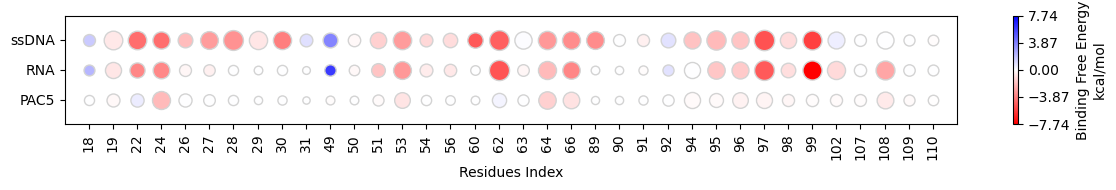

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator, FuncFormatter

df = mergeData.copy()

# 计算点的大小，这里我们用距离的倒数来表示大小，并乘以一个放大因子
size_scale = 400  # 放大因子，可以根据需要调整
df['avg_Dist_PAC5']  = (1 / df['avg_Dist_PAC5'])  * size_scale
df['avg_Dist_RNA']   = (1 / df['avg_Dist_RNA'])   * size_scale
df['avg_Dist_ssDNA'] = (1 / df['avg_Dist_ssDNA']) * size_scale

# 创建画布，减小高度
fig, ax = plt.subplots(figsize=(12, 2))

# 设置y轴的位置
y_positions = {'C5': 0, 'RNA': 0.5, 'ssDNA' : 1}

# 将proNdx转换为分类变量
df['ResID'] = df['ResID'].astype(str)

# 获取唯一的proNdx值，用于x轴标签
unique_proNdx = df['ResID'].unique()

# 自定义颜色映射，负值为红色，正值为蓝色
cmap = LinearSegmentedColormap.from_list('custom', ['red', 'white', 'blue'], N=256)

# 计算颜色映射的范围，确保0点对称
max_eng = max(df['avg_BFE_PAC5'].abs().max(), df['avg_BFE_RNA'].abs().max(), df['avg_BFE_ssDNA'].abs().max())
print('DF shape:', df.shape)
print('unique ResID:', unique_proNdx.size)
# 绘制PAC5点
for index, row in df.iterrows():
    ax.scatter(unique_proNdx.tolist().index(row['ResID']), y_positions['C5'], s=row['avg_Dist_PAC5'], c=row['avg_BFE_PAC5'], cmap=cmap, vmin=-max_eng, vmax=max_eng, edgecolors='lightgray')

# 绘制RNA点
for index, row in df.iterrows():
    ax.scatter(unique_proNdx.tolist().index(row['ResID']), y_positions['RNA'], s=row['avg_Dist_RNA'], c=row['avg_BFE_RNA'], cmap=cmap, vmin=-max_eng, vmax=max_eng, edgecolors='lightgray')

# 绘制ssDNA点
for index, row in df.iterrows():
    ax.scatter(unique_proNdx.tolist().index(row['ResID']), y_positions['ssDNA'], s=row['avg_Dist_ssDNA'], c=row['avg_BFE_ssDNA'], cmap=cmap, vmin=-max_eng, vmax=max_eng, edgecolors='lightgray')

# 设置图例
ax.set_xlabel('Residues Index')
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['PAC5', 'RNA', 'ssDNA'])
#ax.set_title('Dotplot of RNA and ssDNA')

# 设置x轴刻度
ax.set_xticks(range(len(unique_proNdx)))
ax.set_xticklabels(unique_proNdx, rotation=90)#, ha='right')  # 旋转标签以提高可读性

# 设置y轴范围，增加一些空间以避免点被裁剪
y_margin = 0.4  # y轴边缘的额外空间
ax.set_ylim(-0.4, 1.4 )

ax.set_xlim(-1, 36)

# 添加颜色条
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-max_eng, max_eng)), ax=ax)
cbar.set_label('Binding Free Energy\nkcal/mol')

# 设置颜色条的刻度
tick_locator = FixedLocator([-max_eng, -max_eng/2, 0, max_eng/2, max_eng])
cbar.ax.yaxis.set_major_locator(tick_locator)
#cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}"))

# 显示图形
plt.tight_layout()  # 调整布局以适应刻度标签

# 保存图像
plt.savefig('../Pics/dotplot.png', dpi=300, bbox_inches='tight')  # 保存为PNG格式，300 DPI，自动调整布局
plt.savefig('../Pics/dotplot.svg', bbox_inches='tight')  # 保存为PNG格式，300 DPI，自动调整布局
plt.show()